# Dashboard Prototyping: Professional Fintech Visuals

## Visual Analysis Insight
The Volume Z-Score (Orange) clearly leads the price exhaustion. Significant spikes (>2.0) are correlated with local price tops, especially the massive Oct 2025 event.

---

In [47]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(ROOT_DIR)
load_dotenv(os.path.join(ROOT_DIR, '.env'))

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [15, 7]

## 1. Data Ingestion
Loading the Unified Master View from BigQuery.

In [48]:
project_id = os.getenv('GCP_PROJECT_ID')
dataset_id = os.getenv('GCP_DATASET_ID')
client = bigquery.Client(project=project_id)

query = f"SELECT * FROM `{project_id}.{dataset_id}.vw_looker_master_intelligence` ORDER BY ds ASC"
df = client.query(query).to_dataframe()
df['ds'] = pd.to_datetime(df['ds'])

if 'ml_volume_zscore' not in df.columns and 'zscore_30d' in df.columns:
    df['ml_volume_zscore'] = df['zscore_30d']

print(f"[SUCCESS] Dataset loaded: {len(df)} records.")

/Users/charlie/ai_projects/portafolio/crypto-ml-predictor/venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


[SUCCESS] Dataset loaded: 1960 records.


## 2. High-Contrast Overlay: Price & ML Signals
Using a clearer color scheme to ensure the price trend is visible behind the ML markers.

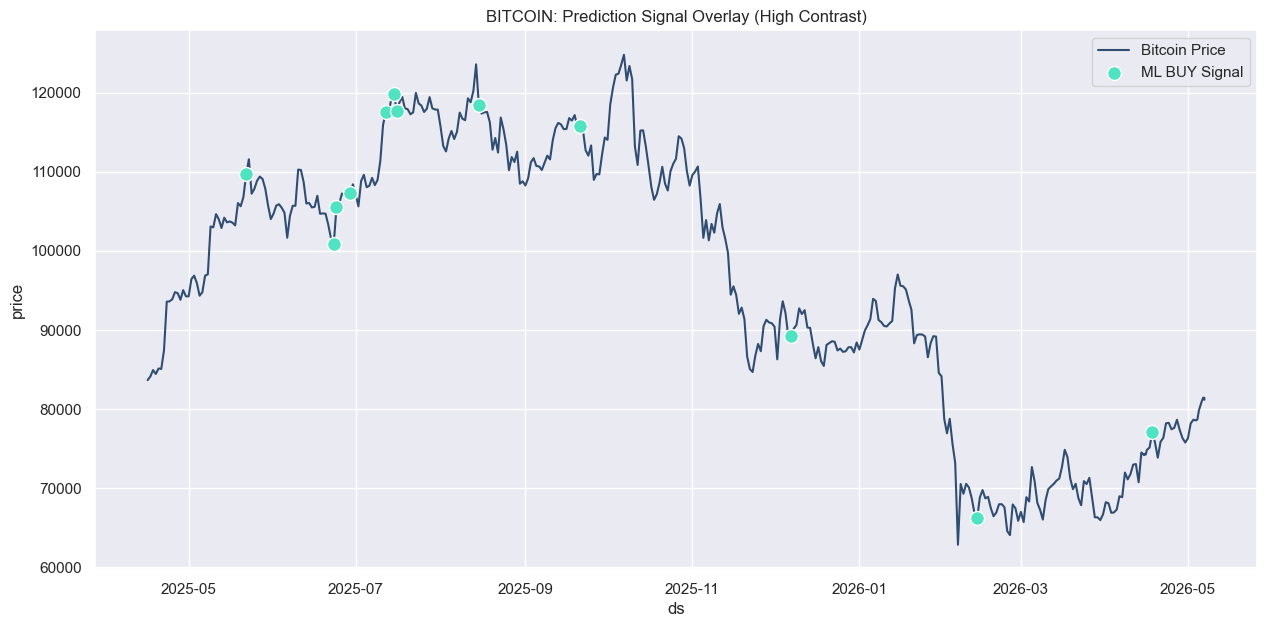

In [49]:
asset_id = 'bitcoin'
subset = df[df['id'] == asset_id].copy()

fig, ax = plt.subplots()
# SENIOR FIX: Better color and higher alpha for the price line
sns.lineplot(data=subset, x='ds', y='price', ax=ax, label='Bitcoin Price', color="#002652", alpha=0.8)

# Bullish Signals (Teal Dots)
bullish = subset[subset['ml_prediction'] == 1]
ax.scatter(bullish['ds'], bullish['price'], color='#50E3C2', label='ML BUY Signal', s=100, edgecolor='white', zorder=5)

plt.title(f"{asset_id.upper()}: Prediction Signal Overlay (High Contrast)")
plt.legend()
plt.show()

## 3. The Market Pulse: Exhaustion Zones
Highlighting the 'Shock Zones' where volume threatens the price stability.

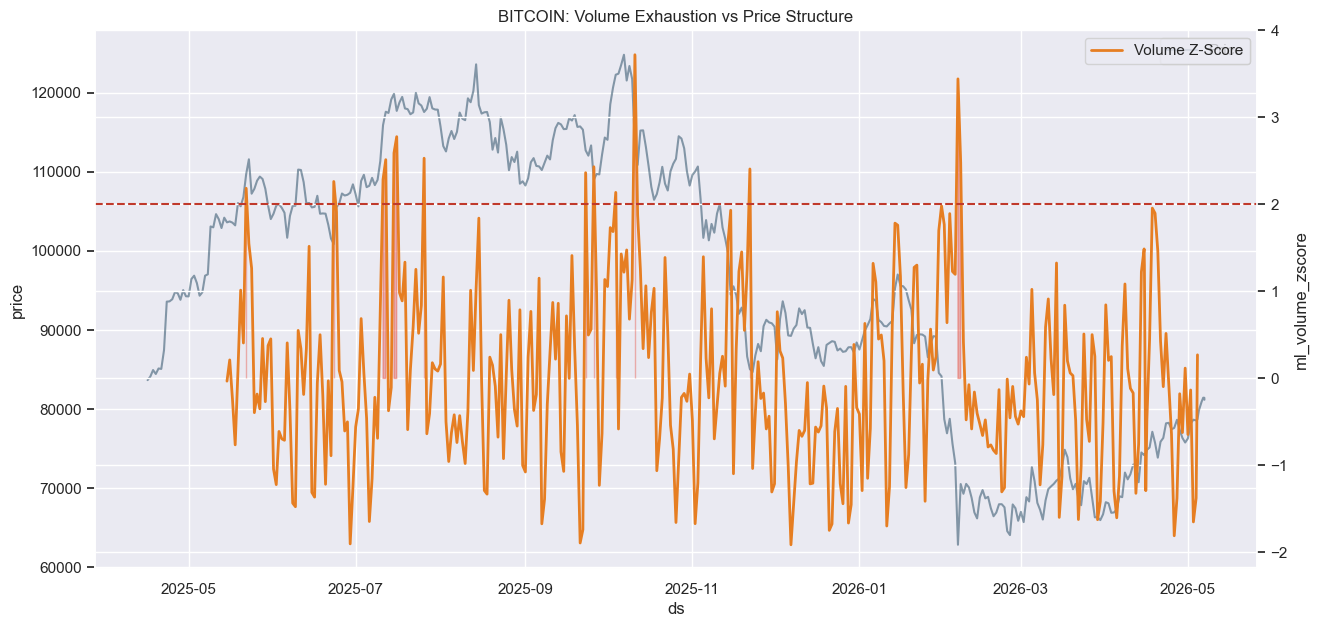

In [50]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Price Background (Subtle but visible)
sns.lineplot(data=subset, x='ds', y='price', ax=ax1, color="#1B425C", alpha=0.5, label='Price')

# Z-Score foreground
sns.lineplot(data=subset, x='ds', y='ml_volume_zscore', ax=ax2, color='#E67E22', label='Volume Z-Score', linewidth=2)

# Shock Detection Area
ax2.axhline(2.0, color='#C0392B', linestyle='--', label='Shock Threshold (2.0)')
ax2.fill_between(subset['ds'], 0, subset['ml_volume_zscore'], where=(subset['ml_volume_zscore'] > 2), color='#E74C3C', alpha=0.4)

plt.title(f"{asset_id.upper()}: Volume Exhaustion vs Price Structure")
plt.show()

## 4. Combined Intelligence: Shocks vs Signals
Merging both perspectives into a single 'Super Chart'. This allows us to see if ML signals (Teal Dots) avoid or exploit high-volume exhaustion zones (Red Areas).

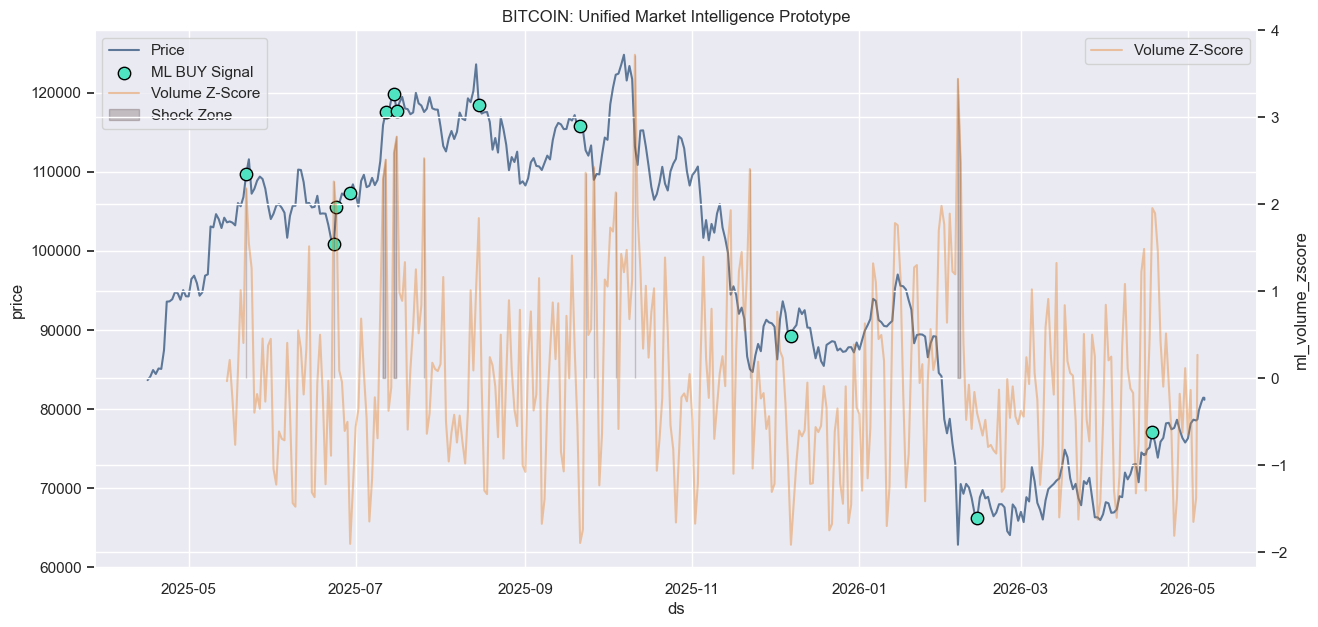

In [51]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# 1. Price and Teal Signals (Primary Axis)
sns.lineplot(data=subset, x='ds', y='price', ax=ax1, color="#002B5C", alpha=0.6, label='Price')
bullish = subset[subset['ml_prediction'] == 1]
ax1.scatter(bullish['ds'], bullish['price'], color='#50E3C2', label='ML BUY Signal', s=80, edgecolor='black', zorder=5)

# 2. Z-Score and Red Zones (Secondary Axis)
sns.lineplot(data=subset, x='ds', y='ml_volume_zscore', ax=ax2, color='#E67E22', label='Volume Z-Score', alpha=0.4)
ax2.fill_between(subset['ds'], 0, subset['ml_volume_zscore'], where=(subset['ml_volume_zscore'] > 2), color="#230400", alpha=0.2, label='Shock Zone')

plt.title(f"{asset_id.upper()}: Unified Market Intelligence Prototype")

# Manual Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

## 5. Macro Monthly Analysis: Structural Risk
Aggregating data by month to visualize long-term 'Volume Tsunamis' and the model's structural risk assessment. This filters daily noise for high-level decision making.

/var/folders/j9/mtv0lz0x6cb1bbktm7dcl8_m0000gn/T/ipykernel_25839/589504906.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = subset.resample('M', on='ds').agg({


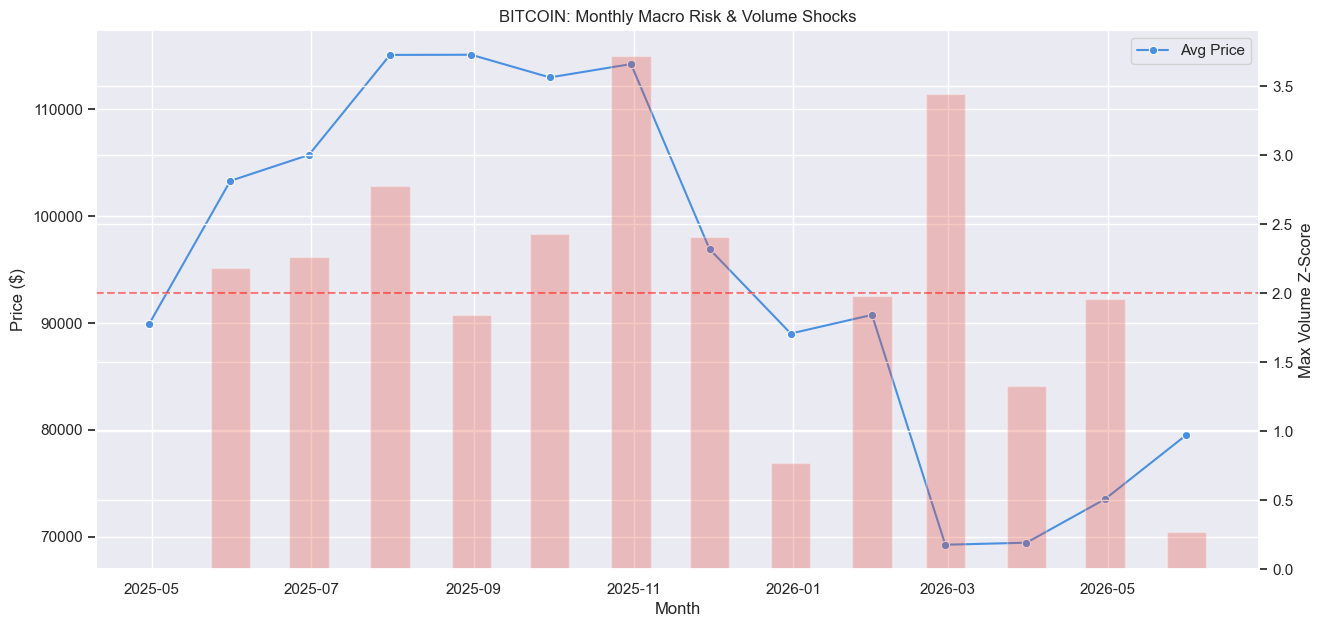

Monthly Macro data ready for Looker design.


In [52]:
# 1. Monthly Aggregation
monthly_df = subset.resample('M', on='ds').agg({
    'price': 'mean',
    'ml_volume_zscore': 'max',  # Focus on the biggest shock of the month
    'ml_probability': 'mean'     # Average confidence of the month
}).reset_index()

# 2. Monthly Visualization
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Price Line (Monthly Avg)
sns.lineplot(data=monthly_df, x='ds', y='price', ax=ax1, marker='o', color='#4A90E2', label='Avg Price')

# Volume Shock Bars (Max Z-Score)
ax2.bar(monthly_df['ds'], monthly_df['ml_volume_zscore'], width=15, color='#E74C3C', alpha=0.3, label='Max Volume Shock')
ax2.axhline(2.0, color='red', linestyle='--', alpha=0.5)

plt.title(f"{asset_id.upper()}: Monthly Macro Risk & Volume Shocks")
ax1.set_xlabel("Month")
ax1.set_ylabel("Price ($)")
ax2.set_ylabel("Max Volume Z-Score")

plt.show()

print("Monthly Macro data ready for Looker design.")

## 6. The Tsunami Impact Map: One-Chart Evidence
This unified chart marks the Top 10 Shocks with vertical lines and shades the following 30 days. Red shading confirms price exhaustion (reversal), while Green shading indicates trend continuation.

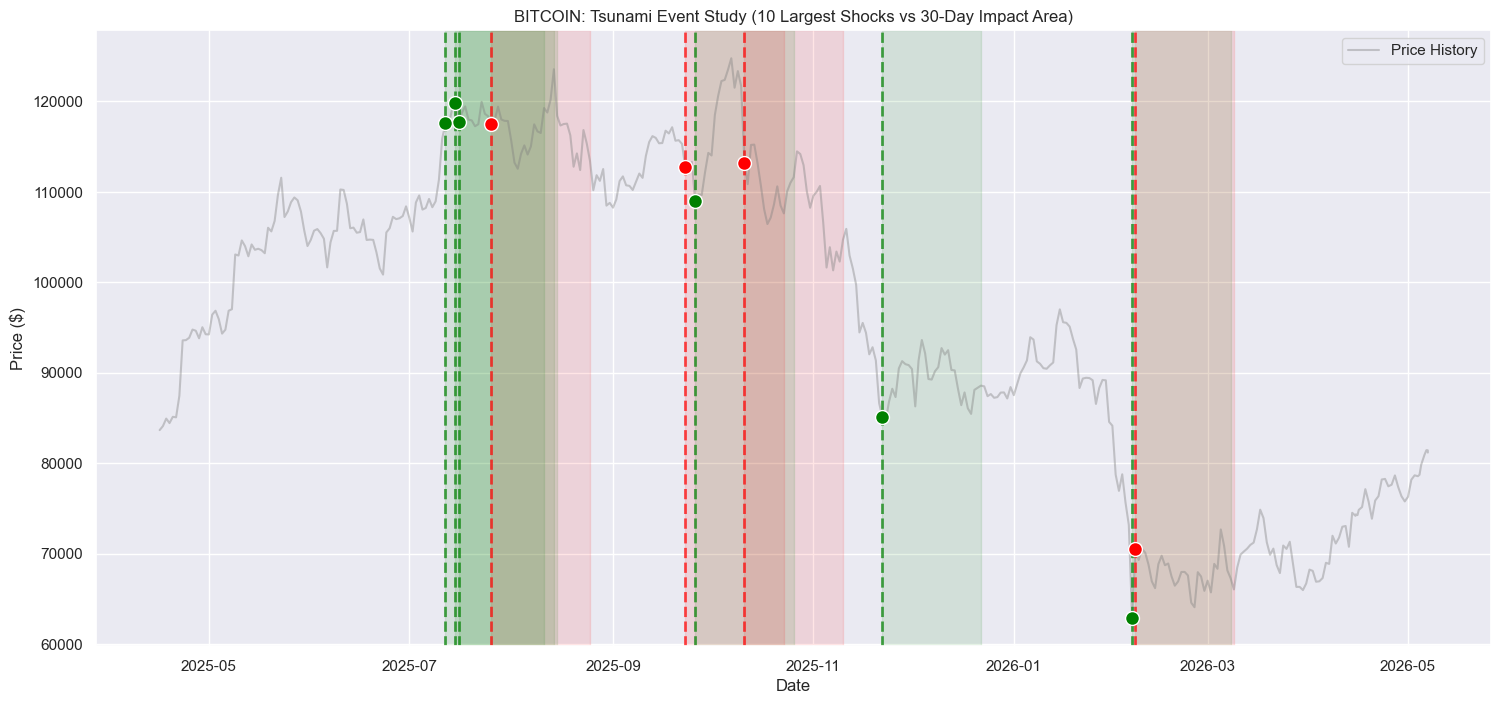

Visual Evidence: Red areas indicate confirmed price exhaustion after a Volume Shock.


In [53]:
import matplotlib.patches as mpatches

# 1. Filter for a specific asset (Bitcoin is best for this)
asset_id = 'bitcoin'
full_data = df[df['id'] == asset_id].sort_values('ds')
top_10 = full_data.sort_values('ml_volume_zscore', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(18, 8))

# 2. Plot Price Line
sns.lineplot(data=full_data, x='ds', y='price', ax=ax, color='gray', alpha=0.4, label='Price History')

# 3. Overlay Tsunamis and Shadow Impact
for idx, row in top_10.iterrows():
    shock_date = row['ds']
    # Define the 30-day window after the shock
    end_date = shock_date + pd.Timedelta(days=30)
    
    # Determine color: Red if price fell, Green if it rose
    impact_color = 'red' if row['return_t30'] < 0 else 'green'
    
    # Draw Vertical Marker
    ax.axvline(shock_date, color=impact_color, linestyle='--', alpha=0.7, linewidth=2)
    
    # Shade the 30-day impact area
    ax.axvspan(shock_date, end_date, color=impact_color, alpha=0.1)
    
    # Add a marker at the point of impact
    ax.scatter(shock_date, row['price'], color=impact_color, s=100, zorder=10, edgecolor='white')

plt.title(f"{asset_id.upper()}: Tsunami Event Study (10 Largest Shocks vs 30-Day Impact Area)")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.show()

print("Visual Evidence: Red areas indicate confirmed price exhaustion after a Volume Shock.")